This program calculates the 3 physio-climatic parameters used for regionalization of calibration parameters. 
Parameters are chosen similar as in 
- Beck, H. E., De Roo, A., and van Dijk, A. I.: Global maps of streamflow characteristics based on observations from several thousand
catchments, Journal of Hydrometeorology, 16, 1478–1501, https://doi.org/10.1175/JHM-D-14-0155.1, 2015.
- Beck, H. E., van Dijk, A. I., De Roo, A., Miralles, D. G., McVicar, T. R., Schellekens, J., and Bruijnzeel, L. A.: Global-scale regionalization
of hydrologic model parameters, Water Resources Research, 52, 3599–3622, https://doi.org/10.1002/2015WR018247, 2016

In [5]:
import netCDF4 as nc 
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
from matplotlib.colors import LinearSegmentedColormap

## Input Filepath and Output Filepath

In [9]:
# Output filepaths 
filepath_BECKparam_data = 'BECKparam_data'
filepath_BECKparam_graphs = 'BECKparam_graphs'
# CWatM input data filepath 
input_filepath = 'Input_data/'

## Data sources
'mean_annual_precipitation.nc' (P [mm/year], mean annual precipitation) taken from MSWX climate data, mean over 1990-2019.

'mean_annual_pet.nc' (PET [mm/year], mean annual potential evapotranspiration) taken from CWatM simulations calculated via Pennman-Montheith equation, mean over 1990-2019.

'mean_annual_ai.nc' (AI [-], mean annual aridity index) calculated from 'mean_annual_pet.nc' & 'mean_annual_precipitation.nc' as AI = PET/P, mean over 1990-2019.

'tanTopo.nc' / 'slope.nc' (SLO [°], surface slope) taken from CWatM input maps; Note: surface slope is not dynamic for different years, no temporal mean.

## Creating Figures

In [20]:
# Corners for central Europe
A_lon, A_lat, B_lon, B_lat = -11, 33, 41.5, 72

data_grid1 = nc.Dataset(input_filepath + 'ETRef_daily.nc')
time_30yearsLTS = data_grid1.variables['time'][:]
longitudes = data_grid1.variables['lon'][:]
latitudes = data_grid1.variables['lat'][:]

# Grid for plotting
lon, lat = np.meshgrid(longitudes, latitudes)
x, y = lon, lat 

x_min, x_max = x.min() - 1, x.max() + 1 
y_min, y_max = y.min() - 1, y.max() + 1 

xr_data_slope_global  = xr.open_dataset(input_filepath   + 'tanslope.nc')
xr_data_slope         = xr_data_slope_global.sel(lon=slice(x_min, x_max), lat=slice(y_max, y_min))
longitudes2 = xr_data_slope['lon'].values
latitudes2 = xr_data_slope['lat'].values

# Grid for CWatM data 
lon2, lat2 = np.meshgrid(longitudes2, latitudes2)
x2, y2 = lon2, lat2 

## STEP 1 MSWX: Precipitation

In [10]:
# Input path
P_file = input_filepath  + 'Precipitation_daily.nc' 

# Read data
xr_data_P  = xr.open_dataset(P_file)

# Mean over time period from 01-01-1990 to 31-12-2019 
xr_data_P_yearlymean         = xr_data_P['Precipitation'].groupby('time.year').sum(dim='time')
xr_data_P_mean_falseUnit     = xr_data_P_yearlymean.mean(dim='year') 
xr_data_P_mean               = xr_data_P_mean_falseUnit * 1000

# Save as nc-file
xr_data_P_mean.name = 'mean_annual_precipitation' 
xr_data_P_mean.attrs['units'] = 'mm/year'
xr_data_P_mean.attrs['long_name'] = 'Mean annual precipitation (1990-2019)'
xr_data_P_mean.to_netcdf(filepath_BECKparam_data + '/' +'mean_annual_precipitation.nc')

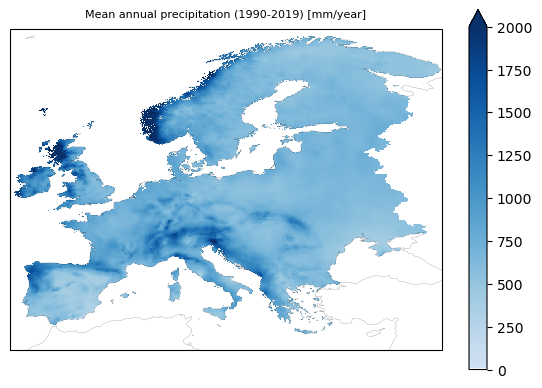

In [11]:
# Colormap for precipitation
colors = plt.cm.Blues(np.linspace(0.2, 1, 256))  # 0.2 removes light blue
colors[0] = [1, 1, 1, 1]  # 0 = Weiß (RGBA)
Blues_new = LinearSegmentedColormap.from_list('WhiteBlues', colors)

# Plotting
fig = plt.figure(figsize=(6, 4))
choosen_projection = ccrs.PlateCarree()
ax = fig.add_axes([0.1, 0.1, 0.9, 0.9], projection=choosen_projection)
ax.set_extent([A_lon, B_lon, A_lat, B_lat], crs=choosen_projection)
ax.coastlines(linewidth=0.1, linestyle='-')
z_color = ax.pcolormesh(x, y, xr_data_P_mean , cmap = Blues_new, vmin = 0, vmax = 2000 )
fig.colorbar(z_color, ax=ax,  orientation='vertical', extend='max')
plt.suptitle('Mean annual precipitation (1990-2019) [mm/year]', fontsize=8, x= 0.46, y= 1.00)
fig.savefig(filepath_BECKparam_graphs + '/' +'mean_annual_precipitation.jpg', dpi=300, bbox_inches='tight')
plt.show()

## STEP 2 CWatM simulations: Potential evapotranspiration, aridity index

In [12]:
# Input path
PET_file = Input_data + 'ETRef_daily.nc' 

# Read data
xr_data_PET  = xr.open_dataset(PET_file)

# Mean over 01-01-1990 bis 31-12-2019 
xr_data_PET_yearlymean         = xr_data_PET['ETRef'].groupby('time.year').sum(dim='time')
xr_data_PET_mean_falseUnit     = xr_data_PET_yearlymean.mean(dim='year') 
xr_data_PET_mean               = xr_data_PET_mean_falseUnit * 1000

# calculate aridity index
xr_data_AI_mean = xr_data_PET_mean / xr_data_P_mean

# Save as nc-file
xr_data_PET_mean.name = 'mean_annual_pet'         
xr_data_PET_mean.attrs['units'] = 'mm/year'
xr_data_PET_mean.attrs['long_name'] = 'Mean annual potential evapotranspiration (1990-2019)'
xr_data_PET_mean.to_netcdf(filepath_BECKparam_data + '/' +'mean_annual_pet.nc')

# Save as nc-file
xr_data_AI_mean.name = 'mean_annual_ai'           
xr_data_AI_mean.attrs['units'] = '-'
xr_data_AI_mean.attrs['long_name'] = 'Aridity index AI = PET/P (1990-2019)'
xr_data_AI_mean.to_netcdf(filepath_BECKparam_data + '/' +'mean_annual_ai.nc')

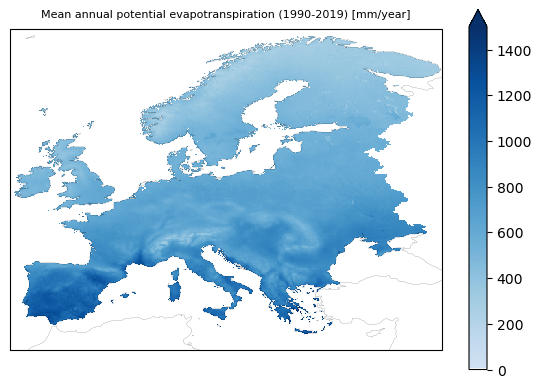

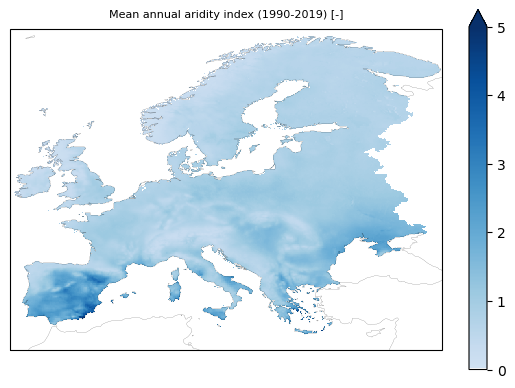

In [13]:
# Plot PET
fig = plt.figure(figsize=(6, 4))
choosen_projection = ccrs.PlateCarree()
ax = fig.add_axes([0.1, 0.1, 0.9, 0.9], projection=choosen_projection)
ax.set_extent([A_lon, B_lon, A_lat, B_lat], crs=choosen_projection)
ax.coastlines(linewidth=0.1, linestyle='-')
z_color = ax.pcolormesh(x, y, xr_data_PET_mean , cmap = Blues_new, vmin = 0, vmax  = 1500 )
fig.colorbar(z_color, ax=ax,  orientation='vertical', extend='max')
plt.suptitle('Mean annual potential evapotranspiration (1990-2019) [mm/year]', fontsize=8, x = 0.46, y = 1.00)
fig.savefig(filepath_BECKparam_graphs + '/' + 'mean_annual_pet.jpg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Plot AI
fig = plt.figure(figsize=(6, 4))
choosen_projection = ccrs.PlateCarree()
ax = fig.add_axes([0.1, 0.1, 0.9, 0.9], projection=choosen_projection)
ax.set_extent([A_lon, B_lon, A_lat, B_lat], crs=choosen_projection)
ax.coastlines(linewidth=0.1, linestyle='-')
z_color = ax.pcolormesh(x, y, xr_data_AI_mean , cmap = Blues_new, vmin = 0, vmax = 5 )
fig.colorbar(z_color, ax=ax,  orientation='vertical', extend='max')
plt.suptitle('Mean annual aridity index (1990-2019) [-]', fontsize=8, x = 0.46, y = 1.00)
fig.savefig(filepath_BECKparam_graphs + '/' +'mean_annual_ai.jpg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## STEP 3 CWatM input data: Surface slope [°] 

In [14]:
# Input path
tanslope_file = input_filepath + 'tanslope.nc'

# Read data
xr_data_tanslope  = xr.open_dataset(tanslope_file)
xr_data_tanslope_value_global = xr_data_tanslope['tanslope']

# Cut to Europe domain
xr_data_tanslope_value = xr_data_tanslope_value_global.sel(lon=slice(x_min, x_max), lat=slice(y_max, y_min))

# Convert tan(slope) [-] to surface slope [°]
xr_data_slope_value = np.arctan(xr_data_tanslope_value) * 180 / np.pi

# Save as nc-file
xr_data_slope_value.name = 'slope'              # [Sina]
# xr_data_slope_value.name = 'tan_topo'         # [Augustin]
xr_data_slope_value.attrs['units'] = '°'
xr_data_slope_value.attrs['long_name'] = 'Surface slope'
xr_data_slope_value.to_netcdf(filepath_BECKparam_data + '/' + 'topography_slope.nc')

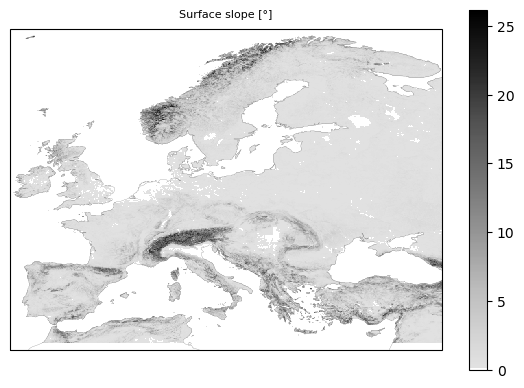

In [15]:
# Colormap
colors = plt.cm.Greys(np.linspace(0.2, 1, 256))  # 0.2 entfernt sehr helles Grau
colors[0] = [1, 1, 1, 1]  # 0 = Weiß
WhiteGrayBlack = LinearSegmentedColormap.from_list('WhiteGrayBlack', colors)

# Plot surface slope
fig = plt.figure(figsize=(6, 4))
choosen_projection = ccrs.PlateCarree()
ax = fig.add_axes([0.1, 0.1, 0.9, 0.9], projection=choosen_projection)
ax.set_extent([A_lon, B_lon, A_lat, B_lat], crs=choosen_projection)
ax.coastlines(linewidth=0.1, linestyle='-')
z_color = ax.pcolormesh(x2, y2, xr_data_slope_value, cmap = WhiteGrayBlack, vmin = 0)
fig.colorbar(z_color, ax=ax,  orientation='vertical' )
plt.suptitle('Surface slope [°]', fontsize=8, x = 0.46, y = 1.00)
fig.savefig(filepath_BECKparam_graphs + '/' +'topography_slope.jpg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()